# S&P 500 Equity + Option Analytics: Feasibility Analysis

This notebook tests whether the S&P 500 equity-with-option-analytics dataset can
deliver on the strategy declared in `config/setup.yaml`. `setup.yaml` is the
canonical, hand-curated source of truth: universe, costs, decision schedule,
mapping class, labels, sweep grid, and evaluation protocol. This notebook does
not write it. Instead, it produces the evidence that justifies its values:
options-coverage breadth per symbol, return distributions at daily and weekly
horizons relative to the 13 bps round-trip cost, autocorrelation support for
the weekly cadence, and a walk-forward fold demonstration. Findings persist to
`config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify options coverage delivers a usable universe (the analog to eligibility)
- Test whether typical equity moves exceed transaction costs at daily and weekly horizons
- Quantify return autocorrelation to support the weekly rebalance choice
- Demonstrate the walk-forward structure fits within the 2017–2021 sample
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- S&P 500 options surface and daily-bars data available via the `data` package
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""S&P 500 Equity + Option Analytics: Feasibility Analysis."""

import json
import warnings
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import yaml
from scipy import stats

from data import load_sp500_daily_bars, load_sp500_options_surface
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
START_DATE = "2017-01-01"
END_DATE = "2021-12-31"
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
ROUND_TRIP_COST_BPS = int(SETUP["costs"]["round_trip_cost_bps"])
ROUND_TRIP_COST = ROUND_TRIP_COST_BPS / 10_000  # 13 bps -> 0.0013


def _expected_trading_days(start_date: str, end_date: str) -> int:
    """Approximate NYSE trading days between two ISO dates (~252/365)."""
    start = datetime.fromisoformat(start_date)
    end = datetime.fromisoformat(end_date)
    calendar_days = (end - start).days
    return int(calendar_days * 252 / 365)

---

## Section A: Orientation (Section 6.2)

This case study trades S&P 500 underlying equities using features derived from
the listed-options market: implied-volatility level and dynamics, skew, term
structure, and the variance-risk-premium gap between IV and realized vol.
Options provide the *features*; the strategy holds the *underlying stocks*.
Decisions are made at Friday close and executed at Monday open, with a one-day
publication lag on IV features to keep the protocol point-in-time.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Is options coverage adequate across the 2017–2021 sample?
- **Costs**: Do typical equity moves exceed the 13 bps round-trip cost at
  daily / weekly horizons?
- **Cadence**: Does the autocorrelation profile support weekly rebalancing?
- **Evaluation**: Do walk-forward folds fit within the 5-year sample and stay
  clear of the 2021 holdout?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify Data

We load both the options surface (for coverage analysis) and daily equity bars
(for return-cost feasibility). The options surface is the binding constraint:
the universe is "S&P 500 constituents *with* options coverage."

In [4]:
surface = load_sp500_options_surface(start_date=START_DATE, end_date=END_DATE)
sp500_bars = load_sp500_daily_bars(start_date=START_DATE, end_date=END_DATE)

print(
    f"Options surface: {surface.height:,} rows, "
    f"{surface['symbol'].n_unique()} symbols, "
    f"{surface['timestamp'].n_unique()} distinct dates"
)
print(f"Equity bars:     {sp500_bars.height:,} rows, {sp500_bars['symbol'].n_unique()} symbols")

Options surface: 530,503 rows, 633 symbols, 1259 distinct dates
Equity bars:     635,703 rows, 638 symbols


### B.2 Universe: Options-Coverage Diagnostic

Unlike ETF case studies where the binding filter is dollar volume, here the
relevant filter is *options-data availability*. We compute per-symbol coverage
against the *expected* number of NYSE trading days in the sample (not against
the dates actually present in the surface, which may have vendor gaps).

Coverage is reported as a *diagnostic* — `setup.yaml::universe.n_assets`
records the full surface universe, and per-date missingness is handled
downstream by feature-level NaN dropping in the modeling notebooks rather than
by a universe-level pre-filter. The 90% line below marks the symbols with
near-complete histories; symbols below it still contribute on the dates where
they have features.

In [5]:
expected_trading_days = _expected_trading_days(START_DATE, END_DATE)
actual_dates_in_data = surface["timestamp"].n_unique()

coverage = (
    surface.group_by("symbol")
    .agg(pl.col("timestamp").n_unique().alias("n_days"))
    .with_columns((pl.col("n_days") / expected_trading_days).alias("coverage"))
    .sort("coverage", descending=True)
)

COVERAGE_THRESHOLD = 0.90
n_symbols = coverage.height
n_above_threshold = int((coverage["coverage"] >= COVERAGE_THRESHOLD).sum())
median_coverage = float(coverage["coverage"].median())
min_coverage = float(coverage["coverage"].min())

print(f"Expected trading days:  {expected_trading_days}")
print(
    f"Actual dates in data:   {actual_dates_in_data} "
    f"(diff={abs(expected_trading_days - actual_dates_in_data)})"
)
print(f"Symbols with options:   {n_symbols}")
print(f"Median symbol coverage: {median_coverage:.1%}")
print(f"Min symbol coverage:    {min_coverage:.1%}")
print(f"Symbols >= {COVERAGE_THRESHOLD:.0%} coverage: {n_above_threshold}")

Expected trading days:  1260
Actual dates in data:   1259 (diff=1)
Symbols with options:   633
Median symbol coverage: 68.2%
Min symbol coverage:    0.2%
Symbols >= 90% coverage: 214


#### Coverage Distribution

The histogram below shows the per-symbol coverage distribution. The 90%
reference line is a diagnostic anchor — the universe is not trimmed to it.
Per-date NaN handling in the feature/modeling stages decides on each
decision date which symbols contribute.

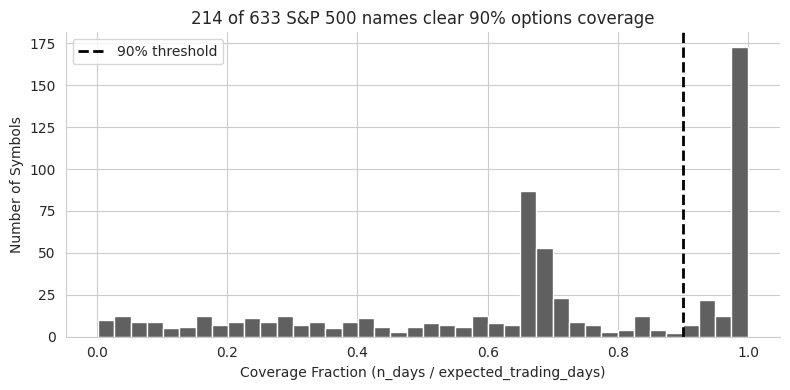

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(coverage["coverage"].to_numpy(), bins=40, color="#606060", edgecolor="white")
ax.axvline(
    COVERAGE_THRESHOLD,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"{COVERAGE_THRESHOLD:.0%} threshold",
)
ax.set_xlabel("Coverage Fraction (n_days / expected_trading_days)")
ax.set_ylabel("Number of Symbols")
ax.set_title(
    f"{n_above_threshold} of {n_symbols} S&P 500 names clear "
    f"{COVERAGE_THRESHOLD:.0%} options coverage"
)
ax.legend(loc="upper left")
sns.despine()
fig.tight_layout()
plt.show()

**Interpretation**: Coverage is heterogeneous — many symbols have partial
histories because of intermittent vendor data or mid-sample S&P 500
inclusion/exclusion. `setup.yaml::universe.n_assets` records the full surface
universe; downstream feature and modeling code drops per-date NaNs so symbols
contribute only on dates where their features are observed.

### B.3 Trading-Cost Analysis: Horizon Feasibility

The strategy trades the underlying equities (not options), so the relevant
cost reference is equity execution: 3–10 bps per leg, i.e., 13 bps round-trip
at the midpoint (6.5 bps × 2 legs). We check whether typical absolute moves
at daily and weekly horizons exceed this floor.

In [7]:
daily_returns = (
    sp500_bars.sort(["symbol", "timestamp"])
    .with_columns((pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return"))
    .filter(pl.col("return").is_not_null())
)

weekly_bars = (
    sp500_bars.with_columns(pl.col("timestamp").dt.strftime("%G-W%V").alias("week"))
    .group_by(["symbol", "week"])
    .agg(pl.col("close").last().alias("close"), pl.col("timestamp").max().alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
weekly_returns = weekly_bars.with_columns(
    (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
).filter(pl.col("return").is_not_null())

daily_abs = daily_returns["return"].abs().to_numpy()
weekly_abs = weekly_returns["return"].abs().to_numpy()

print(f"Daily returns:  {len(daily_abs):,} observations")
print(f"Weekly returns: {len(weekly_abs):,} observations")

Daily returns:  635,053 observations
Weekly returns: 131,204 observations


#### Return Distributions Relative to the Cost Floor

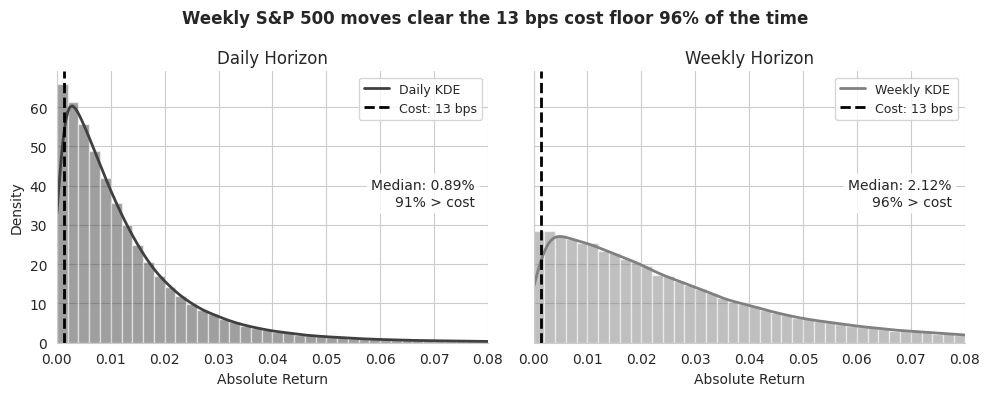

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
horizons = [("Daily", daily_abs, "#404040"), ("Weekly", weekly_abs, "#808080")]

for ax, (label, data, color) in zip(axes, horizons, strict=False):
    data_clipped = data[data < 0.10]
    ax.hist(data_clipped, bins=50, density=True, alpha=0.5, color=color, edgecolor="white")
    if len(data_clipped) > 100:
        kde = stats.gaussian_kde(data_clipped, bw_method=0.1)
        grid = np.linspace(0, 0.08, 200)
        ax.plot(grid, kde(grid), color=color, linewidth=2, label=f"{label} KDE")
    ax.axvline(
        ROUND_TRIP_COST,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Cost: {ROUND_TRIP_COST_BPS} bps",
    )
    frac_above = (data > ROUND_TRIP_COST).mean()
    median_val = float(np.median(data))
    stats_text = f"Median: {median_val * 100:.2f}%\n{frac_above:.0%} > cost"
    # Place the stat box in the empty right tail, clear of the upper-right legend.
    ax.text(
        0.97,
        0.55,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )
    ax.set_title(f"{label} Horizon")
    ax.set_xlabel("Absolute Return")
    ax.set_xlim(0, 0.08)
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Density")
frac_weekly_above = (weekly_abs > ROUND_TRIP_COST).mean()
fig.suptitle(
    f"Weekly S&P 500 moves clear the {ROUND_TRIP_COST_BPS} bps cost floor "
    f"{frac_weekly_above:.0%} of the time",
    fontsize=12,
    fontweight="bold",
)
sns.despine()
fig.tight_layout()
plt.show()

#### Cost-Exceedance Summary

In [9]:
COST_THRESHOLDS_BPS = [5, 10, 15, 20, 30]
cost_rows = []
for horizon_label, data in [("Daily", daily_abs), ("Weekly", weekly_abs)]:
    row = {"horizon": horizon_label}
    for cost_bps in COST_THRESHOLDS_BPS:
        row[f"{cost_bps}_bps"] = float((data > cost_bps / 10_000).mean() * 100)
    cost_rows.append(row)

cost_df = pl.DataFrame(cost_rows)
cost_df.select(
    [
        "horizon",
        pl.col("5_bps").round(1).alias("5 bps %"),
        pl.col("10_bps").round(1).alias("10 bps %"),
        pl.col("15_bps").round(1).alias("15 bps %"),
        pl.col("20_bps").round(1).alias("20 bps %"),
        pl.col("30_bps").round(1).alias("30 bps %"),
    ]
)

horizon,5 bps %,10 bps %,15 bps %,20 bps %,30 bps %
str,f64,f64,f64,f64,f64
"""Daily""",96.7,93.4,90.1,86.9,80.7
"""Weekly""",98.6,97.3,95.9,94.6,91.8


**Interpretation**: For large-cap S&P 500 names, both daily and weekly moves
comfortably clear the 13 bps round-trip floor in the vast majority of
observations. Friction is *not* the binding constraint for this universe; the
binding constraint is feature latency (the 1-day IV publication lag) and signal
persistence at the chosen cadence.

#### Cost-Regime Choice: bps Headline, per-Share Exploratory

`setup.yaml::costs.model = percentage` — costs are declared in basis points
rather than a flat $/share half-spread. S&P 500 constituents are liquid
large-caps with a relatively narrow price distribution ($50–$500 nominal
range in the validation window), so bps and per-share regimes track each
other closely here. The decisive consideration is that prices in this
panel are split-adjusted: a $0.01 half-spread on a $50 split-adjusted
share quotes a different bps friction than the same $0.01 on the
unadjusted share that actually traded. A flat-default per-share cost
applied to adjusted historical prices conflates split adjustment with
realized friction — a known weakness of per-share+spread when the
spread floor is set without reference to name-level liquidity (see
`memory/feedback_per_share_on_adjusted_prices.md`). For nasdaq100, the
analogous case study, we sidestep this by using *measured* per-asset
half-spreads from AlgoSeek NBBO quotes; we do not have an equivalent
vendor product spanning the full S&P 500 universe with split-adjusted
alignment, so the bps regime is the headline. The per-share regime is
retained as an exploratory companion in `16_costs.py` — the disagreement
between regimes is the lesson, not a defect to paper over.

### B.4 Feasibility Ratio

An edge-to-cost ratio at the strategy's declared weekly horizon confirms that
typical move magnitude exceeds the cost floor before we proceed further.

In [10]:
median_weekly_abs_return = float(np.median(weekly_abs))
feasibility_ratio = median_weekly_abs_return / ROUND_TRIP_COST
print(
    f"Median weekly |return|: {median_weekly_abs_return:.4f} "
    f"({median_weekly_abs_return * 10000:.1f} bps)"
)
print(f"Round-trip cost: {ROUND_TRIP_COST:.4f} ({ROUND_TRIP_COST_BPS} bps)")
print(f"Edge-to-cost ratio: {feasibility_ratio:.1f}x")
print(f"Assessment: {'PROCEED' if feasibility_ratio > 1.0 else 'KILL -- edge too thin'}")

Median weekly |return|: 0.0212 (211.6 bps)
Round-trip cost: 0.0013 (13 bps)
Edge-to-cost ratio: 16.3x
Assessment: PROCEED


### B.5 Autocorrelation Support for Weekly Cadence

Weekly cadence is motivated by IV persistence: if IV features are highly
autocorrelated at the daily horizon, daily rebalancing adds costs without
capturing new information. Equity-return autocorrelation at lag-1 and lag-5
is the simplest read on whether the underlying price process itself
contains daily-frequency edge to exploit.

In [11]:
acf_results = (
    daily_returns.with_columns(
        pl.col("return").shift(1).over("symbol").alias("ret_lag1"),
        pl.col("return").shift(5).over("symbol").alias("ret_lag5"),
    )
    .drop_nulls()
    .select(
        pl.corr("return", "ret_lag1").alias("acf_lag1"),
        pl.corr("return", "ret_lag5").alias("acf_lag5"),
    )
    .row(0, named=True)
)
acf_lag1 = float(acf_results["acf_lag1"])
acf_lag5 = float(acf_results["acf_lag5"])
print(f"Return autocorrelation: lag-1 = {acf_lag1:+.4f}, lag-5 = {acf_lag5:+.4f}")
print("Both lags are near zero — daily moves are predominantly noise from a")
print("price-process perspective, consistent with the weekly cadence in setup.yaml.")

Return autocorrelation: lag-1 = -0.0222, lag-5 = +0.0143
Both lags are near zero — daily moves are predominantly noise from a
price-process perspective, consistent with the weekly cadence in setup.yaml.


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the YAML.

### C.1 Decision Cadence

`setup.yaml::decision.cadence: weekly_friday_close` is chosen for three
converging reasons:

1. **Signal persistence**: Implied-volatility features are slow-moving by
   construction (interpolated across strikes and maturities, smoothed by the
   options surface). Daily rebalancing on IV signals adds turnover without
   materially refreshing the information set.
2. **Underlying autocorrelation**: Daily equity returns show negligible
   autocorrelation at lag 1 and lag 5 (B.5 above), so there is no daily-grade
   edge in the price process itself that a higher-frequency strategy would
   capture.
3. **Cost headroom at the weekly horizon**: Weekly absolute moves comfortably
   exceed the 13 bps round-trip cost in the vast majority of observations
   (B.3 above).

Execution timing — `decision.snapshot: friday_16:00_et`,
`decision.execution_delay: monday_open`, `decision.iv_feature_lag: 1_day` —
keeps the protocol point-in-time: IV features observed at one Friday close
are used to make decisions executed at the *next* Monday open, with a one-day
lag absorbing any end-of-day publication delay on the surface.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints — if any triggers, the strategy
is abandoned or substantially reworked. Anchored to the feasibility evidence
above (cost-exceedance, edge-to-cost, autocorrelation):

- **KC1 (IC floor)**: Cross-sectional IC < 0.01 with t-stat < 2.0 across all
  IV-derived families. Gate: Chapter 7–8 feature evaluation.
- **KC2 (edge–cost)**: Edge-to-cost ratio < 1.0x at the weekly horizon after
  realistic transaction costs. B.4 above tests this gate on raw return
  magnitudes before the model is even trained.
- **KC3 (IV redundancy)**: Incremental IC of IV-derived features over plain
  realized-volatility features is ≤ 0. If options-derived signals add nothing
  beyond what RV already captures, the multi-source design has no payoff.
  Gate: Chapter 8 + Chapter 13 model-comparison panel.

### C.3 Mapping Class

`setup.yaml::mapping` declares the simplest credible mapping: **long-only,
equal-weight, rank by IV signal** (`mapping.class:
long_only_rank_and_rebalance`, `sizing: equal_weight`, `entry_logic:
rank_by_iv_signal`). Long-only is appropriate because (a) the case study
trades S&P 500 underlyings, which are easy to long but introduce short-side
borrow and locate frictions outside the scope of this teaching example,
(b) it isolates the ranking signal from short-side complexity, and (c) it
keeps the comparison to an equal-weight S&P 500 benchmark clean. Equal-weight
sizing is the minimal-assumption rule — it avoids introducing a secondary
optimization (risk-parity, inverse-vol, MVO) that would confound evaluation
of the IV-derived ranking signal itself. Chapter 17 explores alternative
weighting schemes via the `backtest.sweep.allocators` grid in `setup.yaml`.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`,
`holdout_start`). The 5-year sample (2017–2021) constrains depth: with a
2-year rolling train window and a 1-year test window, we get two
non-overlapping validation folds (test years 2019 and 2020), then the 2021
holdout.

### D.1 Effective Sample Size and Data Coverage

In [12]:
start_dt = datetime.fromisoformat(START_DATE)
end_dt = datetime.fromisoformat(END_DATE)
years_of_data = (end_dt - start_dt).days / 365.25
weeks_per_year = 52
raw_decisions = int(weeks_per_year * years_of_data)

print("Data Coverage:")
print(f"  Period: {START_DATE} to {END_DATE} ({years_of_data:.1f} years)")
print(f"  Raw weekly decision points: ~{raw_decisions}")
print(f"  Universe at >= {COVERAGE_THRESHOLD:.0%} coverage: {n_above_threshold} symbols")
print(
    "  Effective sample size: Lower due to IV-feature persistence "
    "(~1 quasi-independent obs per month per symbol)"
)

Data Coverage:
  Period: 2017-01-01 to 2021-12-31 (5.0 years)
  Raw weekly decision points: ~259
  Universe at >= 90% coverage: 214 symbols
  Effective sample size: Lower due to IV-feature persistence (~1 quasi-independent obs per month per symbol)


### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters to
verify the data supports the declared design. Each fold has:

- **Train window**: `setup.yaml::evaluation.train_size` (2Y)
- **Test window**: `setup.yaml::evaluation.val_size` (1Y)
- **Purge gap**: 2 weeks between train end and test start (covers the 10-day
  forward-return variant)

In [13]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
purge_weeks = 2  # covers the fwd_ret_10d variant buffer
train_weeks = 2 * weeks_per_year
test_weeks = 1 * weeks_per_year
step_weeks = 1 * weeks_per_year

# Friday-aligned decision dates within the CV window (before holdout)
weekly_dates = (
    sp500_bars.with_columns(pl.col("timestamp").dt.strftime("%G-W%V").alias("week"))
    .group_by("week")
    .agg(pl.col("timestamp").max().alias("timestamp"))
    .sort("timestamp")["timestamp"]
    .to_list()
)
holdout_start_dt = pl.Series([HOLDOUT_START]).str.to_date("%Y-%m-%d").item()
cv_dates = [d for d in weekly_dates if d < holdout_start_dt]

splits = []
test_start_idx = train_weeks
while test_start_idx + test_weeks <= len(cv_dates):
    train_start_idx = test_start_idx - train_weeks
    train_end_idx = test_start_idx - purge_weeks
    test_end_idx = test_start_idx + test_weeks

    split = {
        "fold": len(splits) + 1,
        "train_start": cv_dates[train_start_idx].strftime("%Y-%m-%d"),
        "train_end": cv_dates[train_end_idx - 1].strftime("%Y-%m-%d"),
        "test_start": cv_dates[test_start_idx].strftime("%Y-%m-%d"),
        "test_end": cv_dates[test_end_idx - 1].strftime("%Y-%m-%d"),
        "purge_weeks": purge_weeks,
    }
    splits.append(split)
    test_start_idx += step_weeks

print(f"Generated {len(splits)} walk-forward folds (cv dates: {len(cv_dates)})")
assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
last_test_end = splits[-1]["test_end"]
print(f"Last fold test end: {last_test_end}  |  Holdout start: {HOLDOUT_START}")
assert last_test_end < HOLDOUT_START, (
    f"Last fold ({last_test_end}) overlaps holdout ({HOLDOUT_START})"
)

Generated 2 walk-forward folds (cv dates: 209)
Last fold test end: 2020-12-24  |  Holdout start: 2021-01-01


**Walk-forward fold summary:**

In [14]:
splits_df = pl.DataFrame(splits)
splits_df

fold,train_start,train_end,test_start,test_end,purge_weeks
i64,str,str,str,str,i64
1,"""2017-01-06""","""2018-12-14""","""2019-01-04""","""2019-12-27""",2
2,"""2018-01-05""","""2019-12-13""","""2020-01-03""","""2020-12-24""",2


---

## Section E: Coverage Artifact

Per-symbol options-coverage is the one decision-relevant derived artifact
this notebook generates (everything else lives in `setup.yaml`). Downstream
feature-construction code (`03_financial_features.py`) consumes the
threshold rule directly via `data.load_sp500_options_surface()`, but
persisting the per-symbol table here gives readers a quick sanity check
without re-loading the surface.

In [15]:
coverage_path = CASE_DIR / "config" / "exploration" / "coverage.csv"
# Secondary sort on symbol makes the persisted artifact deterministic (ties on
# coverage would otherwise reorder across runs).
coverage.select(["symbol", "n_days", "coverage"]).sort(
    ["coverage", "symbol"], descending=[True, False]
).write_csv(coverage_path)
print(f"Written: {coverage_path} ({coverage.height:,} symbols)")

Written: /home/stefan/ml4t/code/case_studies/sp500_equity_option_analytics/config/exploration/coverage.csv (633 symbols)


---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This section
enumerates each declared knob alongside the feasibility evidence above that
motivates it. `setup.yaml` is not regenerated here — it is the hand-curated
source of truth, and this notebook reads it.

In [16]:
median_d_abs_pct = float(np.median(daily_abs) * 100)
median_w_abs_pct = float(np.median(weekly_abs) * 100)
frac_d_above_cost = float((daily_abs > ROUND_TRIP_COST).mean())
frac_w_above_cost = float((weekly_abs > ROUND_TRIP_COST).mean())
n_folds_generated = int(len(splits))

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(
    f"universe.n_assets = {SETUP['universe']['n_assets']}  "
    f"(rule = {SETUP['universe']['eligibility_rule']})"
)
print(f"  -> symbols in options surface: {n_symbols}")
print(f"  -> symbols >= {COVERAGE_THRESHOLD:.0%} coverage: {n_above_threshold}")
print(f"  -> median symbol coverage: {median_coverage:.1%}")

print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |weekly return| = {median_w_abs_pct:.2f}%; "
    f"{frac_w_above_cost * 100:.0f}% exceed {ROUND_TRIP_COST_BPS} bps RT"
)
print(
    f"  -> return autocorrelation lag-1 = {acf_lag1:+.4f}, "
    f"lag-5 = {acf_lag5:+.4f} (near zero -> weekly cadence justified)"
)
print(
    f"  -> iv_feature_lag = {SETUP['decision']['iv_feature_lag']} "
    f"(absorbs end-of-day IV publication delay)"
)

print()
print(
    f"costs.class = {SETUP['costs']['class']} "
    f"({SETUP['costs']['round_trip_cost_bps']} bps RT, "
    f"per-leg range {SETUP['costs']['per_leg_cost_bps_range']})"
)
print(f"  -> at {ROUND_TRIP_COST_BPS} bps RT: weekly edge-to-cost = {feasibility_ratio:.0f}x")
print(f"  -> daily moves > {ROUND_TRIP_COST_BPS} bps: {frac_d_above_cost * 100:.0f}%")

print()
print(f"mapping.class = {SETUP['mapping']['class']} (sizing = {SETUP['mapping']['sizing']})")
print("  -> long-only, equal-weight; IV-derived ranking signal evaluated in Chapters 7-8")

print()
print(f"labels.primary = {SETUP['labels']['primary']}  (buffer = {SETUP['labels']['buffer']})")
print(
    f"  -> median |weekly return| = {median_w_abs_pct:.2f}% = "
    f"{(median_w_abs_pct / 100) / ROUND_TRIP_COST:.0f}x a "
    f"{ROUND_TRIP_COST_BPS} bps RT cost"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print("  -> 10d / risk-adjusted / direction variants; buffer 10D covers the longest horizon")

print()
print(
    f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}  "
    f"(train_size = {SETUP['evaluation']['train_size']}, "
    f"val_size = {SETUP['evaluation']['val_size']})"
)
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(f"  -> holdout {HOLDOUT_START} to {HOLDOUT_END}; last test ends {splits[-1]['test_end']}")

Setup.yaml knobs vs feasibility evidence

universe.n_assets = 633  (rule = sp500_with_options)
  -> symbols in options surface: 633
  -> symbols >= 90% coverage: 214
  -> median symbol coverage: 68.2%

decision.cadence = weekly_friday_close
  -> median |weekly return| = 2.12%; 96% exceed 13 bps RT
  -> return autocorrelation lag-1 = -0.0222, lag-5 = +0.0143 (near zero -> weekly cadence justified)
  -> iv_feature_lag = 1_day (absorbs end-of-day IV publication delay)

costs.class = material (13 bps RT, per-leg range [3, 10])
  -> at 13 bps RT: weekly edge-to-cost = 16x
  -> daily moves > 13 bps: 91%

mapping.class = long_only_rank_and_rebalance (sizing = equal_weight)
  -> long-only, equal-weight; IV-derived ranking signal evaluated in Chapters 7-8

labels.primary = fwd_ret_5d  (buffer = 10D)
  -> median |weekly return| = 2.12% = 16x a 13 bps RT cost

labels.variants = ['fwd_ret_10d', 'fwd_ret_risk_adj_5d', 'fwd_dir_5d', 'fwd_dir_10d']
  -> 10d / risk-adjusted / direction variants; buffe

### Persist Feasibility Findings

In [17]:
feasibility_report = {
    "case_study_id": STRATEGY_ID,
    "computed_at_utc": datetime.now(UTC).isoformat(),
    "data_period": {"start": START_DATE, "end": END_DATE},
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_symbols_in_surface": int(n_symbols),
        "n_symbols_above_coverage_threshold": int(n_above_threshold),
        "coverage_threshold": float(COVERAGE_THRESHOLD),
        "median_coverage": float(median_coverage),
        "min_coverage": float(min_coverage),
        "expected_trading_days": int(expected_trading_days),
        "actual_dates_in_data": int(actual_dates_in_data),
    },
    "return_distribution_abs_pct": {
        "daily_median": median_d_abs_pct,
        "weekly_median": median_w_abs_pct,
    },
    "cost_exceedance_pct": {
        "round_trip_cost_bps": ROUND_TRIP_COST_BPS,
        "daily": frac_d_above_cost * 100,
        "weekly": frac_w_above_cost * 100,
    },
    "feasibility_ratio_weekly": float(feasibility_ratio),
    "autocorrelation": {
        "lag_1": acf_lag1,
        "lag_5": acf_lag5,
    },
    "walk_forward": {
        "n_folds_generated": n_folds_generated,
        "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
        "train_weeks": train_weeks,
        "test_weeks": test_weeks,
        "purge_weeks": purge_weeks,
        "holdout_start": HOLDOUT_START,
        "holdout_end": HOLDOUT_END,
        "last_test_end": splits[-1]["test_end"],
    },
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
print(f"Written: {report_path}")

Written: /home/stefan/ml4t/code/case_studies/sp500_equity_option_analytics/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: Options coverage is the binding eligibility filter. A 90%
   coverage threshold against expected NYSE trading days admits a broad
   S&P 500 sample; `setup.yaml::universe.n_assets` records the post-filter
   count.
2. **Cost feasibility**: Both daily and weekly absolute moves clear the
   13 bps round-trip cost in the vast majority of observations. Friction is
   *not* the binding constraint for this liquid large-cap universe.
3. **Cadence**: Weekly Friday-close is anchored to IV-feature persistence
   (signals are slow-moving by construction) and the near-zero autocorrelation
   of daily returns (no daily-grade edge in the price process to chase).
4. **Mapping**: Long-only equal-weight as the simplest credible baseline;
   alternative allocators sweep in `setup.yaml::backtest.sweep.allocators`
   (explored in Chapter 17).
5. **Evaluation**: Two walk-forward folds (test years 2019 and 2020) fit the
   5-year sample; the 2021 holdout is cleanly separated by a 2-week purge
   that covers the 10-day forward-return variant.
6. **Kill conditions**: KC2 (edge-to-cost > 1.0x) already cleared —
   feasibility ratio at the weekly horizon is comfortably above 1.0 on raw
   return magnitudes. KC1 (IC floor) and KC3 (IV redundancy over RV) are
   tested in later chapters.

**Known limitations**:
- The 5-year sample (2017–2021) is short relative to most equity case
  studies; effective sample size is further reduced by IV persistence.
- Coverage thresholding is fraction-based against expected trading days; a
  symbol may pass the 90% test yet still have multi-week gaps within its
  observed window. Downstream feature pipelines should re-check at decision
  time.
- Layer-1 survivorship bias (the universe is defined as S&P 500 *with*
  options coverage as observed in the dataset) is documented but not
  resolved.

**Artifacts written**:
- `config/exploration/coverage.csv`: per-symbol options-coverage table.
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running.

**Next**: Chapter 7 (`02_labels.py`) creates 5-day and 10-day forward equity
returns plus risk-adjusted and direction variants declared in
`setup.yaml::labels`.